In [7]:
from ultralytics import YOLO
import numpy as np
import matplotlib.pyplot as plt

from src.analysis import (
    build_split_summary_and_class_counts,
    collect_bbox_size_data,
    collect_small_images,
)

from src.recall import (
    calculate_recall,
    collect_yolo_predictions,
    evaluate_recall,
)

from src.utils import (
    change_file_type,
    analyze_missed_objects,
)



In [8]:
YOLO_PATH = "./yolo26n.pt"
DATA_DIR = "./data"

In [9]:
summary_df, class_distributions = build_split_summary_and_class_counts(DATA_DIR)
bbox_size_rows, bbox_size_df = collect_bbox_size_data(DATA_DIR)
small_images = collect_small_images(bbox_size_rows, split_name="train")
small_images = small_images[:3]
images_paths = list(zip(small_images, [change_file_type(v) for v in small_images]))

In [10]:
model = YOLO(YOLO_PATH)

saved_predictions = collect_yolo_predictions(
    model,
    small_images,
    confidence=0.2,
)

recall_summary = evaluate_recall(
    images_paths,
    saved_predictions,
    conf_threshold=0.2,
    iou_threshold=0.1,
)

print(f"TP:     {recall_summary.true_positives}")
print(f"FN:     {recall_summary.false_negatives}")
print(f"GT:     {recall_summary.ground_truth_count}")
print(f"Recall: {recall_summary.recall:.4f}")

TP:     0
FN:     264
GT:     264
Recall: 0.0000


In [11]:
missed, class_stats, size_stats, tb = analyze_missed_objects(
    images_paths,
    saved_predictions,
    iou_threshold=0.5,
    conf_threshold=0.2,
)

print("Missed objects:", len(missed))

print("\nMisses by class:")
for cls, count in class_stats.most_common():
    print(f"class {cls}: {count}")

print("\nMisses by size:")
for size, count in size_stats.items():
    print(f"{size}: {count}")

Missed objects: 465

Misses by class:
class 2: 462
class 7: 3

Misses by size:
tiny: 465


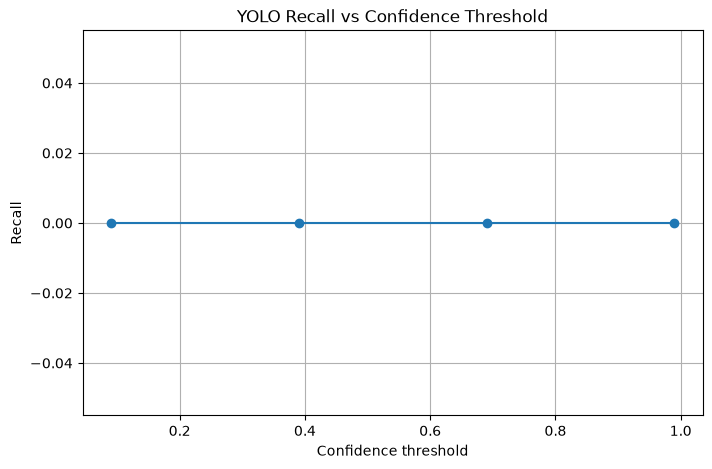

In [14]:
thresholds = np.arange(0.09, 1.0, 0.3, dtype=float)

recalls = [
    calculate_recall(
        images_paths[:1000],
        saved_predictions[:1000],
        conf_threshold=0.5,
        iou_threshold=trshold,
    )
    for trshold in thresholds
]

plt.figure(figsize=(8, 5))
plt.plot(thresholds, recalls, marker="o")
plt.xlabel("Confidence threshold")
plt.ylabel("Recall")
plt.title("YOLO Recall vs Confidence Threshold")
plt.grid()
plt.show()